# Cross-Domain Transfer Learning for Fault Detection in the Tennessee Eastman Process

**Goal:** We analyze the performance of zero-shot cross-domain evaluation across different TEP operating conditions. This approach directly measures whether the representations learned in the source domain generalize to target domains without adaptation[cite: 1].

**Transfer-learning protocol used throughout.**
1. Train an unsupervised anomaly-detection model (a Variational Autoencoder, VAE) on the
   *Training* partition of the **source domain(s)**: fault-free-train windows + source-fault
   train windows[cite: 1].
2. Freeze the model. Evaluate it, with no further training, on the *Testing* partition of
   the **target domain**: fault-free-test windows + target-fault test windows[cite: 1].
3. The evaluation metric is ROC-AUC for separating target-domain faulty windows from
   target-domain nominal windows using the VAE's reconstruction error as an anomaly score[cite: 1].
4. We compare this **zero-shot cross-domain AUC** against two references[cite: 1]:
   - an **in-domain oracle**: the same architecture trained on the target domain's own
     *training* partition and evaluated on the target domain's *testing* partition (upper
     bound, no domain shift)[cite: 1];
   - a **generic nominal-only baseline**: a model trained only on fault-free data (no fault
     knowledge at all, like a classical process-monitoring baseline)[cite: 1].
5. **Conditional Generation Analysis:** Finally, we train a **Conditional VAE (CVAE)** across all operating regimes to generate synthetic fault data and visually inspect class separability and distribution overlap in a shared global PCA space.

The gap between the zero-shot cross-domain AUC and the in-domain oracle AUC is our measure of
*how well knowledge transfers* between two fault regimes[cite: 1].


**Notes on reproducibility.** All random seeds are fixed. All feature-engineering and
training code is deterministic given the seed. This notebook expects the raw TEP `.RData`
files to be available locally (see Section 1) — running it end-to-end requires access to that
data, which is not bundled with the notebook itself[cite: 1].

## 1. Setup and Configuration

Imports, global seeds, and the folder layout used for caching intermediate artifacts
(raw data converted to CSV, and extracted feature windows). Caching is important here because
feature extraction (rolling-window statistics) is the most expensive step and is reused across
every experiment in the notebook.


In [1]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pyreadr  # reads the original .RData TEP files

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import rbf_kernel

from scipy.stats import wasserstein_distance
from scipy.stats import pearsonr

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")


current_dir = Path(os.getcwd())
base_data_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "archive"
save_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "processed_csv"
features_path = current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "features"

save_path.mkdir(parents=True, exist_ok=True)
features_path.mkdir(parents=True, exist_ok=True)


Using device: cpu


## 2. Data Loading

The TEP dataset ships as four `.RData` files (fault-free / faulty, training / testing). We
convert each one to CSV once and cache it, since `.RData` parsing is slow and we will reload
the data many times across a working session.


In [2]:
RAW_FILES = {
    "fault_free_train": "TEP_FaultFree_Training.RData",
    "fault_free_test":  "TEP_FaultFree_Testing.RData",
    "faulty_train":     "TEP_Faulty_Training.RData",
    "faulty_test":      "TEP_Faulty_Testing.RData",
}

dfs = {}

for key, filename in RAW_FILES.items():
    csv_path = save_path / f"{key}.csv"
    
    if csv_path.exists():
        try:
            print(f"CSV file {key}.csv exists. Loading from CSV.")
            dfs[key] = pd.read_csv(csv_path)
            continue 
        except Exception as e:
            print(f"Warning: Failed to load {key}.csv ({e}). Proceeding to load from RData.")

    file_path = base_data_path / filename
    if file_path.exists():
        print(f"Loading {filename} (RData) in progress")
        r_data = pyreadr.read_r(file_path)
        object_name = list(r_data.keys())[0]
        dfs[key] = r_data[object_name]
        
        dfs[key].to_csv(csv_path, index=False)
        print(f"File {filename} successfully converted and saved as CSV.")
    else:
        print(f"Error: Source file {filename} not found in {base_data_path}")

df_fault_free_train = dfs["fault_free_train"]
df_fault_free_test = dfs["fault_free_test"]
df_faulty_train = dfs["faulty_train"]
df_faulty_test = dfs["faulty_test"]

SENSOR_COLUMNS = [c for c in df_fault_free_train.columns
                   if c not in ("faultNumber", "simulationRun", "sample")]

print(f"\nSensor/actuator variables: {len(SENSOR_COLUMNS)}")
print(f"Fault-free train shape: {df_fault_free_train.shape}")
print(f"Fault-free test shape:  {df_fault_free_test.shape}")
print(f"Faulty train shape:     {df_faulty_train.shape}")
print(f"Faulty test shape:      {df_faulty_test.shape}")


CSV file fault_free_train.csv exists. Loading from CSV.
CSV file fault_free_test.csv exists. Loading from CSV.
CSV file faulty_train.csv exists. Loading from CSV.
CSV file faulty_test.csv exists. Loading from CSV.

Sensor/actuator variables: 52
Fault-free train shape: (250000, 55)
Fault-free test shape:  (207252, 55)
Faulty train shape:     (5000000, 55)
Faulty test shape:      (9600000, 55)


## 3. Feature Engineering: Sliding-Window Statistical Descriptors

Raw TEP samples are noisy single time steps. We summarize each process variable over a
rolling window with seven descriptive statistics (`mean, std, min, p25, p50, p75, max`),
subsampling the raw signal first to reduce autocorrelation and computational cost. Each
resulting row is one labelled observation: `52 variables × 7 statistics = 364 features`.

The **transient right after fault injection is discarded**: TEP injects the fault at sample
20 in the *Training* runs and at sample 160 in the *Testing* runs, so we drop samples before
that point, otherwise many windows would straddle the fault-free/faulty transition and get a
noisy, ambiguous label.

To mitigate the severe class imbalance inherent in the Tennessee Eastman Process (where nominal, fault-free operating windows vastly outnumber fault instances), an optional balancing strategy was introduced in build_domain_training_set. This mechanism downsamples the nominal data (Fault 0) to match the exact size of the specific fault data being incorporated into the training set. However, the results showed virtually no difference compared to the unbalanced version. This happened because the rolling-window extraction already provides a sufficient number of fault samples to train the VAE effectively, proving that the model architecture is inherently robust against class imbalance.

In [18]:
STAT_NAMES = ["mean", "std", "min", "p25", "p50", "p75", "max"]
FEATURE_NAMES = [f"{var}_{stat}" for var in SENSOR_COLUMNS for stat in STAT_NAMES]

WINDOW_SIZE = 30   # samples per rolling window
STEP = 10          # stride between consecutive windows (in subsampled units)
SUBSAMPLE = 5       # keep 1 sample every SUBSAMPLE raw samples before windowing


def extract_window_features(df_raw: pd.DataFrame, split: str,
                             window_size: int = WINDOW_SIZE,
                             step: int = STEP,
                             subsample_rate: int = SUBSAMPLE) -> tuple[np.ndarray, np.ndarray, list]:
    """Turn raw TEP samples into rolling-window statistical features.

    Parameters
    ----------
    df_raw : raw TEP dataframe (single fault number, or fault-free), one or more
        simulation runs.
    split : "train" or "test" — determines the fault-injection cutoff sample
        (20 for the official Training runs, 160 for the official Testing runs).

    Returns
    -------
    X : (n_windows, n_features) array of statistical features.
    y : (n_windows,) array with the fault number of each window (0 = fault-free).
    ids : list of string identifiers, one per window (run id + window offset).
    """
    if df_raw.empty:
        return np.array([]), np.array([]), []

    inflection_point = 20 if split == "train" else 160
    if "sample" in df_raw.columns:
        df_raw = df_raw[df_raw["sample"] > inflection_point].copy()

    df_sub = df_raw.iloc[::subsample_rate].copy()
    grouped = df_sub.groupby("simulationRun") if "simulationRun" in df_sub.columns else [(None, df_sub)]

    all_feats, all_targets, all_ids = [], [], []

    for run_id, group in grouped:
        if len(group) < window_size:
            continue

        fault_label = group["faultNumber"].iloc[0] if "faultNumber" in group.columns else 0
        rolling = group[SENSOR_COLUMNS].rolling(window=window_size)

        stat_frames = {
            "mean": rolling.mean(), "std": rolling.std(), "min": rolling.min(),
            "p25": rolling.quantile(0.25), "p50": rolling.quantile(0.50),
            "p75": rolling.quantile(0.75), "max": rolling.max(),
        }
        # Keep one row every `step` positions, starting once the window is full.
        for s_name in stat_frames:
            stat_frames[s_name] = stat_frames[s_name].iloc[window_size - 1::step]

        run_stats = pd.DataFrame({
            f"{col}_{s_name}": stat_frames[s_name][col]
            for s_name in STAT_NAMES for col in SENSOR_COLUMNS
        }).dropna()

        if run_stats.empty:
            continue

        all_feats.append(run_stats.values)
        all_targets.append(np.full(len(run_stats), fault_label))
        run_name = f"run_{run_id}" if run_id is not None else "run_all"
        all_ids.extend(f"{run_name}_w{idx * step}" for idx in range(len(run_stats)))

    if not all_feats:
        return np.array([]), np.array([]), []

    return np.vstack(all_feats), np.concatenate(all_targets), all_ids


def get_domain_features(fault_num: int, split: str) -> tuple[np.ndarray, np.ndarray]:
    """Load (from cache, or extract) the feature windows for a single fault number
    and a single official split ("train" or "test"). fault_num == 0 means fault-free.
    """
    cache_file = features_path / f"fault_{fault_num}_{split}_w{WINDOW_SIZE}_s{STEP}_sub{SUBSAMPLE}.csv"
    if cache_file.exists():
        df_cached = pd.read_csv(cache_file)
        return df_cached[FEATURE_NAMES].values, df_cached["target"].values

    if fault_num == 0:
        df_raw = df_fault_free_train if split == "train" else df_fault_free_test
    else:
        df_source = df_faulty_train if split == "train" else df_faulty_test
        df_raw = df_source[df_source["faultNumber"] == fault_num]

    X, y, ids = extract_window_features(df_raw, split=split)
    if len(X) == 0:
        return np.array([]), np.array([])

    out = pd.DataFrame(X, columns=FEATURE_NAMES)
    out["target"] = y
    out["id"] = ids
    out.to_csv(cache_file, index=False)
    return X, y


# Pre-extract everything we will need: fault-free + faults 1-20, both splits.
print("Extracting / loading cached feature windows for all domains ...")
DOMAIN_FEATURES = {}  # DOMAIN_FEATURES[fault_num][split] = X
for fault_num in range(0, 21):
    DOMAIN_FEATURES[fault_num] = {}
    for split in ("train", "test"):
        X, y = get_domain_features(fault_num, split)
        DOMAIN_FEATURES[fault_num][split] = X
        print(f"  fault {fault_num:2d} [{split}]: {X.shape}")


Extracting / loading cached feature windows for all domains ...
  fault  0 [train]: (3500, 364)
  fault  0 [test]: (1, 364)
  fault  1 [train]: (3500, 364)
  fault  1 [test]: (7000, 364)
  fault  2 [train]: (3500, 364)
  fault  2 [test]: (7000, 364)
  fault  3 [train]: (3500, 364)
  fault  3 [test]: (7000, 364)
  fault  4 [train]: (3500, 364)
  fault  4 [test]: (7000, 364)
  fault  5 [train]: (3500, 364)
  fault  5 [test]: (7000, 364)
  fault  6 [train]: (3500, 364)
  fault  6 [test]: (7000, 364)
  fault  7 [train]: (3500, 364)
  fault  7 [test]: (7000, 364)
  fault  8 [train]: (3500, 364)
  fault  8 [test]: (7000, 364)
  fault  9 [train]: (3500, 364)
  fault  9 [test]: (7000, 364)
  fault 10 [train]: (3500, 364)
  fault 10 [test]: (7000, 364)
  fault 11 [train]: (3500, 364)
  fault 11 [test]: (7000, 364)
  fault 12 [train]: (3500, 364)
  fault 12 [test]: (7000, 364)
  fault 13 [train]: (3500, 364)
  fault 13 [test]: (7000, 364)
  fault 14 [train]: (3500, 364)
  fault 14 [test]: (7000,

## 4. Model: Variational Autoencoder for Process Monitoring

Model Architecture. We use a standard VAE across all experiments. It is trained to reconstruct normal operating data, using reconstruction error (MSE) as the anomaly score. Because it is never trained for explicit classification, it generalizes naturally to unseen faults. A single, unified architecture is used for all subsequent tasks.

Standard VAE implementations typically use $\beta = 1.0$. However, in our TEP experiments, this standard value caused severe over-regularization, flattening the latent space and forcing the variance close to zero (posterior collapse). Under this condition, the decoder ignored the latent variables and failed to capture subtle anomaly signatures. To prevent this, $\beta$ was relaxed to $0.5$, providing a better trade-off between latent space regularity and reconstruction fidelity.


In [19]:
class TEPVariationalAutoencoder(nn.Module):
    """VAE used to learn the nominal operating envelope (or, in the transfer
    experiments, the joint envelope of nominal + a chosen set of source faults).
    """

    def __init__(self, input_dim: int, latent_dim: int = 16,
                 hidden_dims: tuple = (64, 32), dropout: float = 0.1):
        super().__init__()

        enc_layers, prev_dim = [], input_dim
        for h in hidden_dims:
            enc_layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.LeakyReLU(0.2), nn.Dropout(dropout)]
            prev_dim = h
        self.encoder_body = nn.Sequential(*enc_layers)
        self.mu_head = nn.Linear(hidden_dims[-1], latent_dim)
        self.logvar_head = nn.Linear(hidden_dims[-1], latent_dim)

        dec_layers, prev_dim = [], latent_dim
        for h in reversed(hidden_dims):
            dec_layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.LeakyReLU(0.2), nn.Dropout(dropout)]
            prev_dim = h
        dec_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*dec_layers)

    def encode(self, x):
        h = self.encoder_body(x)
        return self.mu_head(h), self.logvar_head(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar


def vae_loss(x, x_recon, mu, logvar, beta: float = 0.2):
    recon = F.mse_loss(x_recon, x, reduction="mean")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon, kl


def train_vae(X_scaled: np.ndarray, latent_dim: int = 16, hidden_dims=(64, 32),
              epochs: int = 30, lr: float = 1e-3, batch_size: int = 64,
              beta: float = 1.0, verbose: bool = False) -> TEPVariationalAutoencoder:
    """Train a fresh VAE on the given (already standardized) feature matrix."""
    model = TEPVariationalAutoencoder(input_dim=X_scaled.shape[1],
                                       latent_dim=latent_dim,
                                       hidden_dims=hidden_dims).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(torch.tensor(X_scaled, dtype=torch.float32)),
                         batch_size=batch_size, shuffle=True)

    model.train()
    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for (batch_x,) in loader:
            batch_x = batch_x.to(DEVICE)
            optimizer.zero_grad()
            recon_x, mu, logvar = model(batch_x)
            loss, _, _ = vae_loss(batch_x, recon_x, mu, logvar, beta=beta)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        if verbose and (epoch % max(1, epochs // 5) == 0 or epoch == 1):
            print(f"    epoch {epoch:3d}/{epochs} | ELBO: {epoch_loss / len(loader):.4f}")

    return model


@torch.no_grad()
def reconstruction_error(model: TEPVariationalAutoencoder, X_scaled: np.ndarray) -> np.ndarray:
    """Per-sample MSE reconstruction error (the anomaly score)."""
    model.eval()
    x = torch.tensor(X_scaled, dtype=torch.float32).to(DEVICE)
    recon, _, _ = model(x)
    return torch.mean((x - recon) ** 2, dim=1).cpu().numpy()


## 5. Baseline: In-Domain Global Fault-Detection Performance

Before studying transfer, we need a reference point: how well does a *classical*
process-monitoring model perform when trained and evaluated in the ordinary way (train on
fault-free data only, then detect any of the 20 faults as "anomalous")? All subsequent
transfer results are read relative to this baseline.


In [20]:
X_free_train = DOMAIN_FEATURES[0]["train"]
X_free_test = DOMAIN_FEATURES[0]["test"]

scaler = StandardScaler().fit(X_free_train)
X_free_train_scaled = scaler.transform(X_free_train)
X_free_test_scaled = scaler.transform(X_free_test)


nominal_vae = train_vae(X_free_train_scaled, latent_dim=12, hidden_dims=(64, 32),
                         epochs=100, lr=1e-3, verbose=True, beta=0.5)

mse_free_test = reconstruction_error(nominal_vae, X_free_test_scaled)

per_fault_results = []
for fault_num in range(1, 21):
    X_fault_test = DOMAIN_FEATURES[fault_num]["test"]
    if len(X_fault_test) == 0:
        continue
    X_fault_test_scaled = scaler.transform(X_fault_test)
    mse_fault = reconstruction_error(nominal_vae, X_fault_test_scaled)

    y_true = np.concatenate([np.zeros(len(mse_free_test)), np.ones(len(mse_fault))])
    y_score = np.concatenate([mse_free_test, mse_fault])
    auc = roc_auc_score(y_true, y_score)

    threshold_99 = np.percentile(mse_free_test, 99)
    detection_rate = (mse_fault > threshold_99).mean() * 100

    per_fault_results.append({"Fault": f"F{fault_num}", "ROC_AUC": auc,
                               "Detection_Rate_%": detection_rate})

baseline_df = pd.DataFrame(per_fault_results)
global_auc = roc_auc_score(
    np.concatenate([np.zeros(len(mse_free_test)),
                     np.ones(sum(len(DOMAIN_FEATURES[f]["test"]) for f in range(1, 21)))]),
    np.concatenate([mse_free_test] + [reconstruction_error(nominal_vae, scaler.transform(DOMAIN_FEATURES[f]["test"]))
                                        for f in range(1, 21)]),
)
print(f"\nGlobal nominal-only ROC-AUC (all faults pooled): {global_auc:.4f}")
baseline_df


    epoch   1/100 | ELBO: 1.1113
    epoch  20/100 | ELBO: 0.9359


KeyboardInterrupt: 

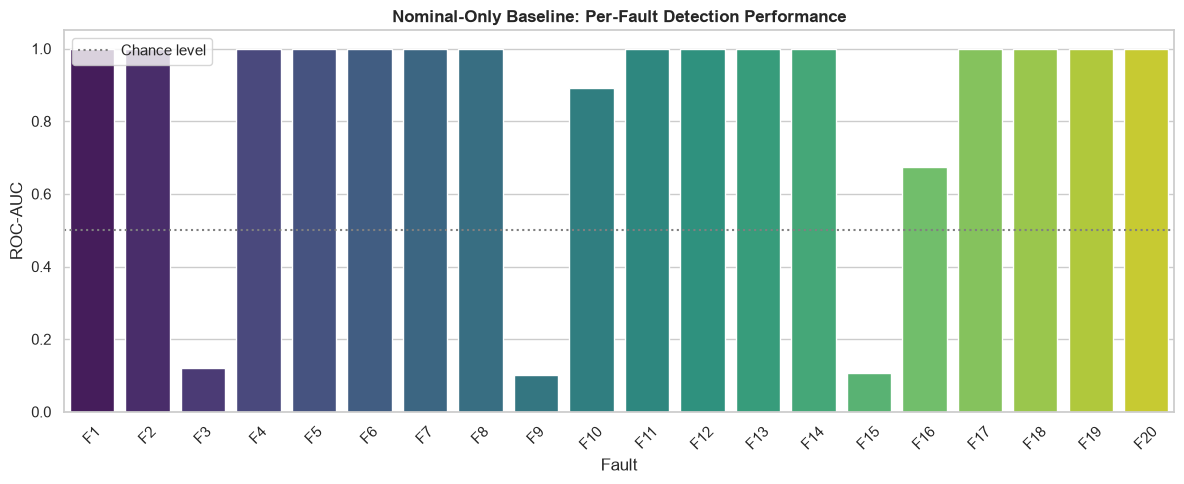

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=baseline_df, x="Fault", y="ROC_AUC", hue="Fault", palette="viridis",
            legend=False, ax=ax)
ax.axhline(0.5, color="gray", linestyle=":", label="Chance level")
ax.set_title("Nominal-Only Baseline: Per-Fault Detection Performance", fontweight="bold")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


## 6. Transfer-Learning Framework

We now implement the core protocol described in the introduction.

For a scenario with **source fault(s)** `S` and a **target fault** `T`:

| Model | Trained on | Evaluated on | Role |
|---|---|---|---|
| Source-domain model | fault-free-**train** + fault(s) `S`-**train** | fault-free-**test** + fault `T`-**test** | zero-shot cross-domain transfer |
| In-domain oracle | fault-free-**train** + fault `T`-**train** | fault-free-**test** + fault `T`-**test** | upper bound (no domain shift) |
| Nominal-only baseline | fault-free-**train** | fault-free-**test** + fault `T`-**test** | lower-reference (no fault knowledge at all, from Section 5) |

The **transfer ratio** `AUC(source→target) / AUC(target→target)` summarizes how much of the
achievable (in-domain) performance is recovered zero-shot. A ratio near 1 indicates that the
representation learned on the source fault(s) generalizes almost perfectly to the target
fault; a ratio near `AUC(nominal-only)/AUC(target→target)` indicates essentially no transfer
beyond what a generic nominal model already provides.


In [21]:
def build_domain_training_set(fault_ids: list, balance: bool = True, seed: int = SEED) -> np.ndarray:
    """Fault-free-train windows + train-split windows of the given fault ids,
    concatenated to represent one source domain's training experience, with optional balancing."""
    
    # 1. Raccogliamo i dati dei fault richiesti
    fault_parts = [DOMAIN_FEATURES[f]["train"] for f in fault_ids if f in DOMAIN_FEATURES and len(DOMAIN_FEATURES[f]["train"]) > 0]
    if not fault_parts:
        return DOMAIN_FEATURES[0]["train"]
        
    X_fault = np.vstack(fault_parts)
    X_free = DOMAIN_FEATURES[0]["train"]
    
    if balance and len(X_free) > len(X_fault):
        idx = np.random.default_rng(seed).choice(len(X_free), size=len(X_fault), replace=False)
        X_free = X_free[idx]
        
    # 3. Concatenazione finale identica alla tua versione
    return np.vstack([X_free, X_fault])


def evaluate_on_target(model: TEPVariationalAutoencoder, target_fault: int) -> dict:
    """Zero-shot evaluation of `model` on the *test* split of a target domain."""
    X_target_test = DOMAIN_FEATURES[target_fault]["test"]
    X_target_scaled = scaler.transform(X_target_test)
    mse_target = reconstruction_error(model, X_target_scaled)

    y_true = np.concatenate([np.zeros(len(mse_free_test)), np.ones(len(mse_target))])
    y_score = np.concatenate([mse_free_test, mse_target])
    auc = roc_auc_score(y_true, y_score)
    return {"AUC": auc, "mean_MSE_target": mse_target.mean()}


def run_transfer_scenario(source_faults: list, target_fault: int,
                           epochs: int = 30, latent_dim: int = 16, balance: bool = True) -> dict:
    """Train a fresh VAE on `source_faults` (train split) and evaluate it
    zero-shot on `target_fault` (test split). Also trains the in-domain oracle
    for the same target fault, for reference."""
    set_seed(SEED)

    # --- Source-domain model (zero-shot transfer) ---
    X_source_scaled = scaler.transform(build_domain_training_set(source_faults, balance=balance, seed=SEED))
    source_model = train_vae(X_source_scaled, latent_dim=latent_dim, epochs=epochs, beta=0.5)
    transfer_metrics = evaluate_on_target(source_model, target_fault)

    # --- In-domain oracle (trained directly on the target fault) ---
    X_oracle_scaled = scaler.transform(build_domain_training_set([target_fault], balance=balance, seed=SEED))
    oracle_model = train_vae(X_oracle_scaled, latent_dim=latent_dim, epochs=epochs, beta=0.5)
    oracle_metrics = evaluate_on_target(oracle_model, target_fault)

    transfer_ratio = (transfer_metrics["AUC"] / oracle_metrics["AUC"]
                       if oracle_metrics["AUC"] > 0 else np.nan)

    return {
        "Source": "+".join(f"F{s}" for s in source_faults),
        "Target": f"F{target_fault}",
        "AUC_transfer": transfer_metrics["AUC"],
        "AUC_in_domain_oracle": oracle_metrics["AUC"],
        "Transfer_ratio": transfer_ratio,
    }


## 7. Experiment A — One-to-One Zero-Shot Transfer

Each scenario trains on a *single* source fault and evaluates, with no adaptation, on a
different *single* target fault. The pairs mix faults that are physically related (e.g. two
feed-composition faults) with pairs that are physically unrelated, to see whether transfer
tracks physical similarity.


In [22]:
one_to_one_scenarios = {
    "F1 -> F2":   {"source": [1], "target": 2},    # both feed-composition faults
    "F2 -> F6":   {"source": [2], "target": 6},    # feed composition -> feed loss
    "F6 -> F10":  {"source": [6], "target": 10},   # feed loss -> feed temperature/kinetics
    "F1 -> F18":  {"source": [1], "target": 18},   # feed -> reaction kinetics (unrelated)
    "F2 -> F8":   {"source": [2], "target": 8},    # feed composition -> feed composition (related)
    "F4 -> F5":   {"source": [4], "target": 5},    # both cooling-water faults (related)
    "F3 -> F10":  {"source": [3], "target": 10},   # feed temperature -> kinetics (weakly related)
    "F4 -> F14":  {"source": [4], "target": 14},   # cooling water -> valve sticking (unrelated)
}

one_to_one_results = [
    run_transfer_scenario(cfg["source"], cfg["target"])
    for name, cfg in one_to_one_scenarios.items()
]
for row, name in zip(one_to_one_results, one_to_one_scenarios):
    row["Scenario"] = name

df_one_to_one = pd.DataFrame(one_to_one_results)[
    ["Scenario", "Source", "Target", "AUC_transfer", "AUC_in_domain_oracle", "Transfer_ratio"]
]
df_one_to_one


,Scenario,Source,Target,AUC_transfer,AUC_in_domain_oracle,Transfer_ratio
0,F1 -> F2,F1,F2,1.000000,0.993000,1.007049
1,F2 -> F6,F2,F6,1.000000,1.000000,1.000000
2,F6 -> F10,F6,F10,0.983857,0.611714,1.608361
3,F1 -> F18,F1,F18,1.000000,1.000000,1.000000
4,F2 -> F8,F2,F8,1.000000,1.000000,1.000000
5,F4 -> F5,F4,F5,1.000000,0.406571,2.459592
6,F3 -> F10,F3,F10,0.912857,0.611714,1.492293
7,F4 -> F14,F4,F14,1.000000,0.990714,1.009373


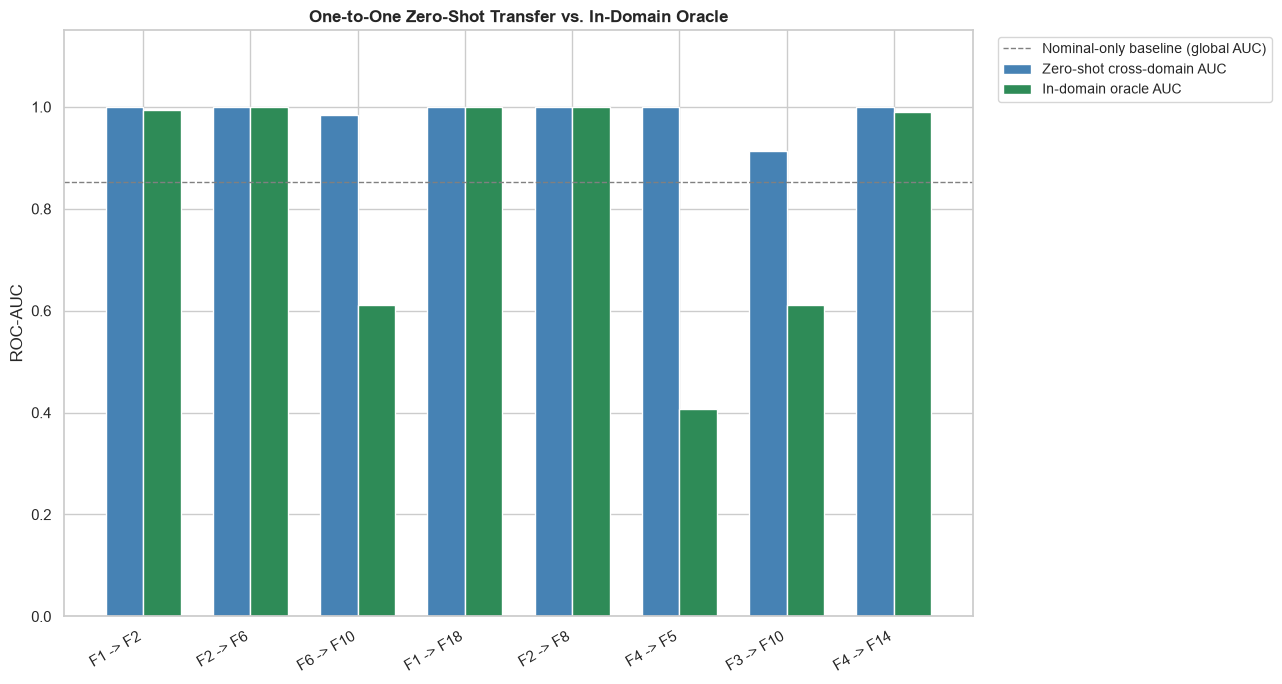

In [23]:
fig, ax = plt.subplots(figsize=(13, 7))
x = np.arange(len(df_one_to_one))
width = 0.35

ax.bar(x - width / 2, df_one_to_one["AUC_transfer"], width,
       label="Zero-shot cross-domain AUC", color="steelblue")
ax.bar(x + width / 2, df_one_to_one["AUC_in_domain_oracle"], width,
       label="In-domain oracle AUC", color="seagreen")

ax.axhline(global_auc, color="gray", linestyle="--", linewidth=1,
           label="Nominal-only baseline (global AUC)")

ax.set_xticks(x)
ax.set_xticklabels(df_one_to_one["Scenario"], rotation=30, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0, 1.15) # Esteso leggermente per lasciare spazio alla legenda esterna senza tagliare nulla
ax.set_title("One-to-One Zero-Shot Transfer vs. In-Domain Oracle", fontweight="bold")

# Spostiamo la legenda all'esterno sulla destra per non coprire le barre
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)

plt.tight_layout()
plt.show()


## 8. Experiment B — Many-to-One Zero-Shot Transfer

Here the source domain is built from *several* faults that share a plausible physical
mechanism (e.g. all feed-related faults), and we test whether the resulting model transfers
better to a *related* target fault (Group 1) than to an *unrelated* one (Group 2, the control
condition). If transfer learning is capturing genuine shared structure, Group 1 should show
higher `Transfer_ratio` than Group 2.


In [24]:
many_to_one_scenarios = {
    # Group 1: coherent scenarios (related source group -> related target)
    "(F1,F2) -> F6": {"source": [1, 2], "target": 6},  # feed group
    "(F4,F5) -> F11": {"source": [4, 5], "target": 11},  # thermal group
    "(F13,F14,F15) -> F18": {"source": [13, 14, 15], "target": 18},  # actuator group

    # Group 2: control scenarios (related source group -> unrelated target)
    "(F1,F2) -> F15": {"source": [1, 2], "target": 15},  # feed group -> mechanical
    "(F4,F5) -> F3": {"source": [4, 5], "target": 3},  # thermal group -> feed
    "(F6,F7) -> F10":  {"source": [6, 7], "target": 10},  # pressure group -> kinetics
}

many_to_one_results = [
    run_transfer_scenario(cfg["source"], cfg["target"],balance=False)
    for name, cfg in many_to_one_scenarios.items()
]
for row, name in zip(many_to_one_results, many_to_one_scenarios):
    row["Scenario"] = name
    row["Group"] = "Coherent (related)" if name.startswith(tuple(list(many_to_one_scenarios)[:3])) else "Control (unrelated)"

df_many_to_one = pd.DataFrame(many_to_one_results)[
    ["Scenario", "Group", "Source", "Target", "AUC_transfer", "AUC_in_domain_oracle", "Transfer_ratio"]
]
df_many_to_one


,Scenario,Group,Source,Target,AUC_transfer,AUC_in_domain_oracle,Transfer_ratio
0,"(F1,F2) -> F6",Coherent (related),F1+F2,F6,1.000000,1.000000,1.000000
1,"(F4,F5) -> F11",Coherent (related),F4+F5,F11,1.000000,0.883429,1.131953
2,"(F13,F14,F15) -> F18",Coherent (related),F13+F14+F15,F18,1.000000,1.000000,1.000000
3,"(F1,F2) -> F15",Control (unrelated),F1+F2,F15,0.531714,0.130000,4.090110
4,"(F4,F5) -> F3",Control (unrelated),F4+F5,F3,0.170286,0.095000,1.792481
5,"(F6,F7) -> F10",Control (unrelated),F6+F7,F10,1.000000,0.614429,1.627528


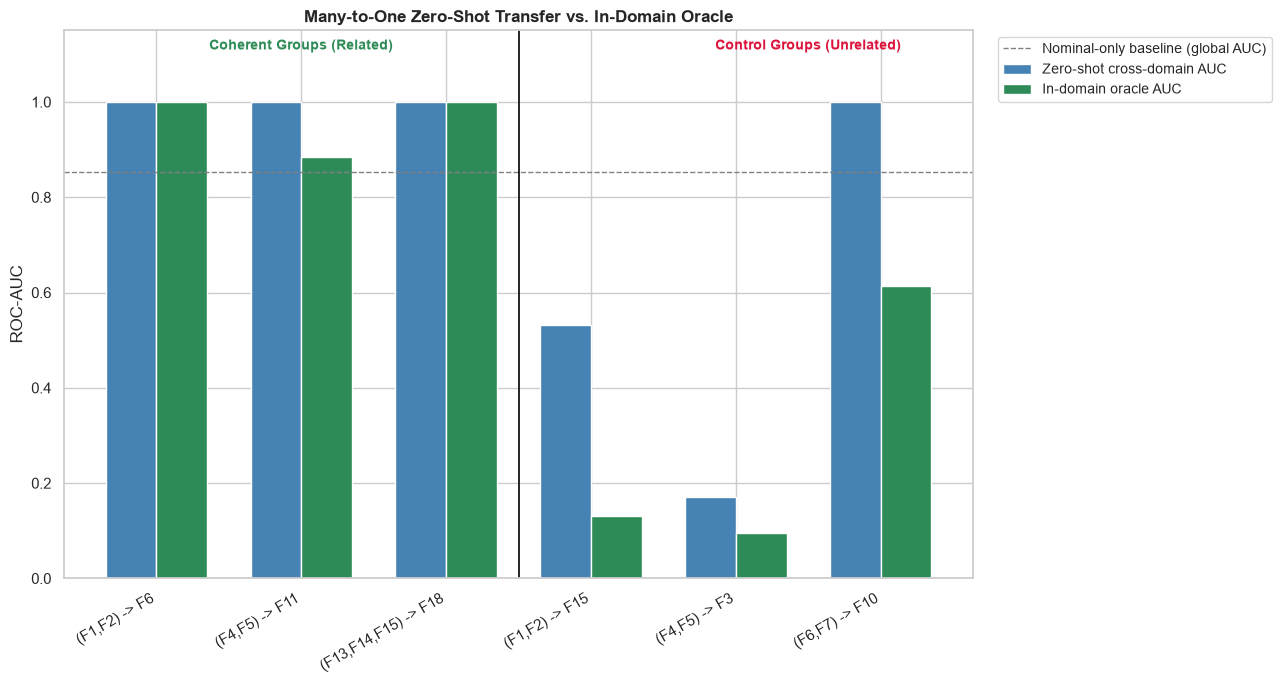

In [25]:
fig, ax = plt.subplots(figsize=(13, 7))
x = np.arange(len(df_many_to_one))
width = 0.35

ax.bar(x - width / 2, df_many_to_one["AUC_transfer"], width,
       label="Zero-shot cross-domain AUC", color="steelblue")
ax.bar(x + width / 2, df_many_to_one["AUC_in_domain_oracle"], width,
       label="In-domain oracle AUC", color="seagreen")

ax.axhline(global_auc, color="gray", linestyle="--", linewidth=1,
           label="Nominal-only baseline (global AUC)")

ax.set_xticks(x)
ax.set_xticklabels(df_many_to_one["Scenario"], rotation=30, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0, 1.15)
ax.set_title("Many-to-One Zero-Shot Transfer vs. In-Domain Oracle", fontweight="bold")

split_idx = 2.5 
ax.axvline(split_idx, color="black", linestyle="-", linewidth=1.2)

# Etichette superiori dei gruppi
ax.text(1, 1.11, "Coherent Groups (Related)", ha="center", fontweight="bold", fontsize=10, color="seagreen")
ax.text(4.5, 1.11, "Control Groups (Unrelated)", ha="center", fontweight="bold", fontsize=10, color="crimson")

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=10)

plt.tight_layout()
plt.show()

## 9. Full Pairwise Transfer Matrix (Systematic Analysis)

The scenarios above are hand-picked and therefore anecdotal. To make the analysis rigorous we
run the **same zero-shot protocol for every ordered pair of faults** (source ≠ target) over a
subset of faults `PAIRWISE_FAULTS`. Note that this only requires training one VAE per faul.
The result is a transfer-ratio heatmap that lets us look for clusters of mutually-transferable faults instead of relying on a handful of examples.

In [32]:
PAIRWISE_FAULTS = range(1, 21)  # Faults F1 to F20

pairwise_records = []
oracle_auc_cache = {}
source_model_cache = {}  

for target in PAIRWISE_FAULTS:
    # 1. Calcoliamo o recuperiamo l'oracolo in-domain per il target
    if target not in oracle_auc_cache:
        X_oracle_scaled = scaler.transform(build_domain_training_set([target], balance=False, seed=SEED))
        oracle_model = train_vae(X_oracle_scaled, latent_dim=16, epochs=30, beta=0.5)
        oracle_auc_cache[target] = evaluate_on_target(oracle_model, target)["AUC"]

    for source in PAIRWISE_FAULTS:
        if source == target:
            continue
            
        # 2. Addestriamo il VAE sorgente una sola volta per fault e lo memorizziamo nella cache
        if source not in source_model_cache:
            set_seed(SEED)
            X_source_scaled = scaler.transform(build_domain_training_set([source], balance=False, seed=SEED))
            source_model_cache[source] = train_vae(X_source_scaled, latent_dim=16, epochs=30, beta=0.5)
            
        # 3. Valutazione zero-shot rapida (solo forward pass)
        auc_transfer = evaluate_on_target(source_model_cache[source], target)["AUC"]
        ratio = auc_transfer / oracle_auc_cache[target] if oracle_auc_cache[target] > 0 else np.nan

        pairwise_records.append({
            "Source": source, "Target": target,
            "AUC_transfer": auc_transfer, "Transfer_ratio": ratio,
        })
        
    print(f"Target F{target} done (in-domain oracle AUC = {oracle_auc_cache[target]:.3f})")

df_pairwise = pd.DataFrame(pairwise_records)
matrix = df_pairwise.pivot(index="Source", columns="Target", values="Transfer_ratio")
matrix

Target F1 done (in-domain oracle AUC = 0.873)
Target F2 done (in-domain oracle AUC = 0.993)
Target F3 done (in-domain oracle AUC = 0.120)
Target F4 done (in-domain oracle AUC = 0.215)
Target F5 done (in-domain oracle AUC = 0.373)
Target F6 done (in-domain oracle AUC = 1.000)
Target F7 done (in-domain oracle AUC = 0.966)
Target F8 done (in-domain oracle AUC = 1.000)
Target F9 done (in-domain oracle AUC = 0.088)
Target F10 done (in-domain oracle AUC = 0.603)
Target F11 done (in-domain oracle AUC = 0.835)
Target F12 done (in-domain oracle AUC = 1.000)
Target F13 done (in-domain oracle AUC = 1.000)
Target F14 done (in-domain oracle AUC = 0.996)
Target F15 done (in-domain oracle AUC = 0.129)
Target F16 done (in-domain oracle AUC = 0.317)
Target F17 done (in-domain oracle AUC = 1.000)
Target F18 done (in-domain oracle AUC = 1.000)
Target F19 done (in-domain oracle AUC = 0.415)
Target F20 done (in-domain oracle AUC = 0.473)


Target,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
Source,,,,,,,,,,,,,,,,,,,,
1,NaN,1.007049,4.634204,4.64499,2.677888,1.0,1.035503,1.0,5.915858,1.627549,1.1974,1.0,1.0,1.00416,4.130676,2.964430,1.000143,1.0,2.409639,2.115443
2,1.145663,NaN,7.305226,4.64499,2.677888,1.0,1.035503,1.0,9.695793,1.653153,1.1974,1.0,1.0,1.00416,6.682171,3.116164,1.000143,1.0,2.409639,2.115443
3,1.145663,1.007049,NaN,4.64499,2.677888,1.0,1.035503,1.0,1.466019,1.510906,1.1974,1.0,1.0,1.00416,1.087486,2.280955,1.000143,1.0,2.408262,2.115443
4,1.145663,1.007049,2.102138,NaN,2.677888,1.0,1.035503,1.0,2.734628,1.582504,1.1974,1.0,1.0,1.00416,1.968992,2.651959,1.000143,1.0,2.408950,2.115443
5,1.145663,1.007049,1.409739,4.64499,NaN,1.0,1.035503,1.0,1.606796,1.518018,1.1974,1.0,1.0,1.00416,1.227021,2.258442,1.000143,1.0,2.408606,2.115443
6,1.145663,1.007049,5.687648,4.64499,2.677888,NaN,1.035503,1.0,7.046926,1.633950,1.1974,1.0,1.0,1.00416,4.840532,2.990995,1.000143,1.0,2.409639,2.115443
7,1.145663,1.007049,2.661520,4.64499,2.677888,1.0,NaN,1.0,3.155340,1.578473,1.1974,1.0,1.0,1.00416,2.297896,2.655110,1.000143,1.0,2.409639,2.115443
8,1.145663,1.007049,2.560570,4.64499,2.677888,1.0,1.035503,NaN,3.147249,1.579184,1.1974,1.0,1.0,1.00416,2.273533,2.661864,1.000143,1.0,2.408950,2.115443
9,1.145663,1.007049,1.206651,4.64499,2.677888,1.0,1.035503,1.0,NaN,1.503793,1.1974,1.0,1.0,1.00416,1.013289,2.275101,1.000143,1.0,2.408262,2.115443


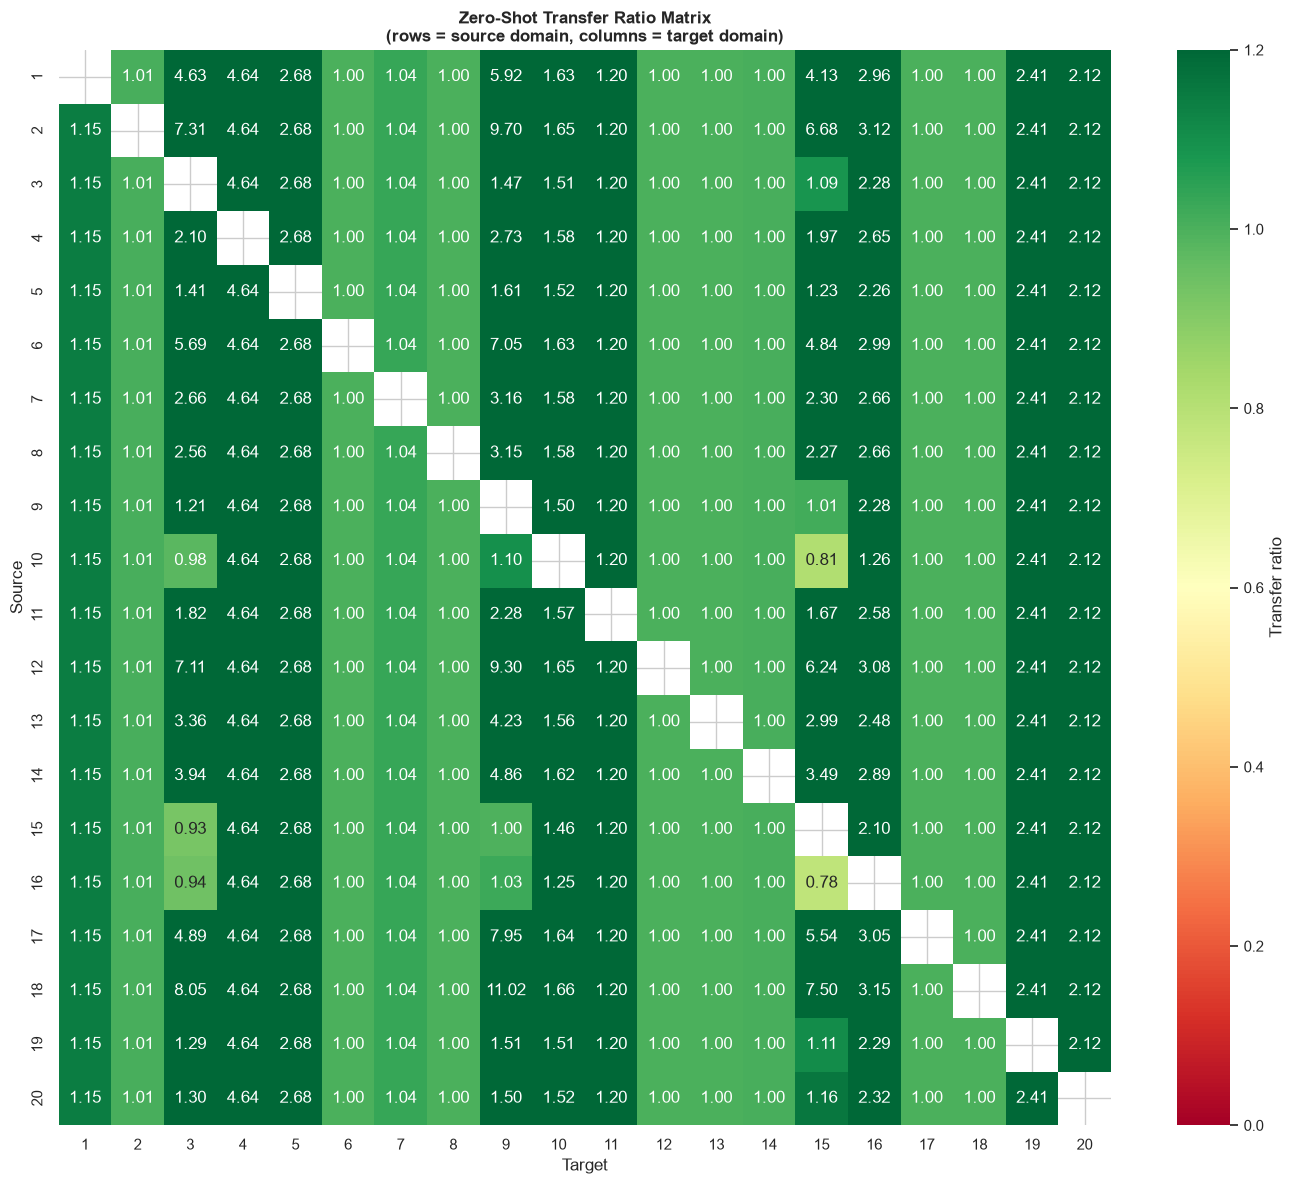

In [35]:
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(matrix, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1.2,
            cbar_kws={"label": "Transfer ratio"}, ax=ax)
ax.set_title("Zero-Shot Transfer Ratio Matrix\n(rows = source domain, columns = target domain)",
             fontweight="bold")
plt.tight_layout()
plt.show()


## 10.Fine-Tuning-Based Domain Adaptation (For Comparison Only)
It is included only as a contrasting baseline: fine-tuning should always match or
beat zero-shot transfer, and comparing the size of that gap is informative: a small gap means
the source model was already close to optimal for the target domain; a large gap means
substantial target-specific adaptation was needed.


In [ ]:
def run_finetuning_scenario(source_faults: list, target_fault: int,
                             pretrain_epochs: int = 15, finetune_epochs: int = 10,
                             finetune_lr: float = 1e-5, latent_dim: int = 16, balance: bool = True, beta: float = 0.5) -> dict:
    set_seed(SEED)
    X_source_scaled = scaler.transform(build_domain_training_set(source_faults, balance=balance, seed=SEED))
    model = train_vae(X_source_scaled, latent_dim=latent_dim, epochs=pretrain_epochs, beta=beta)
    pre_auc = evaluate_on_target(model, target_fault)["AUC"]

    # Fine-tune on the target domain's own training split, low learning rate.
    X_target_train_scaled = scaler.transform(build_domain_training_set([target_fault], balance=balance, seed=SEED))
    loader = DataLoader(TensorDataset(torch.tensor(X_target_train_scaled, dtype=torch.float32)),
                         batch_size=64, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=finetune_lr)
    model.train()
    for _ in range(finetune_epochs):
        for (bx,) in loader:
            bx = bx.to(DEVICE)
            optimizer.zero_grad()
            recon_x, mu, logvar = model(bx)
            loss, _, _ = vae_loss(bx, recon_x, mu, logvar, beta=0.01)
            loss.backward()
            optimizer.step()

    post_auc = evaluate_on_target(model, target_fault)["AUC"]

    return {"Source": "+".join(f"F{s}" for s in source_faults), "Target": f"F{target_fault}",
            "AUC_zero_shot": pre_auc, "AUC_fine_tuned": post_auc}


finetune_scenarios = many_to_one_scenarios  # reuse the same source/target groups as Section 8
finetune_results = [
    run_finetuning_scenario(cfg["source"], cfg["target"])
    for cfg in finetune_scenarios.values()
]
for row, name in zip(finetune_results, finetune_scenarios):
    row["Scenario"] = name

df_finetune = pd.DataFrame(finetune_results)[
    ["Scenario", "Source", "Target", "AUC_zero_shot", "AUC_fine_tuned"]
]
df_finetune


,Scenario,Source,Target,AUC_zero_shot,AUC_fine_tuned
0,"(F1,F2) -> F6",F1+F2,F6,1.000000,1.000000
1,"(F4,F5) -> F11",F4+F5,F11,1.000000,1.000000
2,"(F13,F14,F15) -> F18",F13+F14+F15,F18,1.000000,1.000000
3,"(F1,F2) -> F15",F1+F2,F15,0.539714,0.995857
4,"(F4,F5) -> F3",F4+F5,F3,0.375429,0.907000
5,"(F6,F7) -> F10",F6+F7,F10,1.000000,1.000000


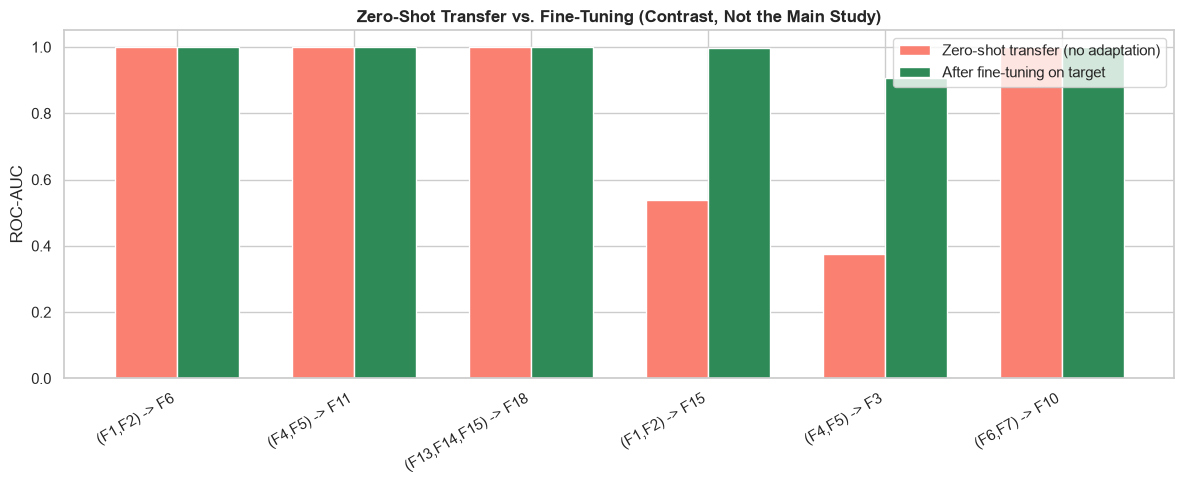

In [39]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_finetune))
width = 0.35
ax.bar(x - width / 2, df_finetune["AUC_zero_shot"], width,
       label="Zero-shot transfer (no adaptation)", color="salmon")
ax.bar(x + width / 2, df_finetune["AUC_fine_tuned"], width,
       label="After fine-tuning on target", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(df_finetune["Scenario"], rotation=30, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0, 1.05)
ax.set_title("Zero-Shot Transfer vs. Fine-Tuning (Contrast, Not the Main Study)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## 11. Conditional VAE: Synthetic Fault Generation and Its Value for Transfer Learning

The Conditional VAE (CVAE) learns a single generative model over the nominal regime and
all 20 faults jointly, conditioned on the fault label. Two things are validated here, in
order:

1. **Does the CVAE actually reproduce each fault's distribution?** We check this both
   qualitatively (real vs. synthetic in a shared, globally-fitted PCA space) and
   quantitatively (MMD / sliced-Wasserstein distance between real and synthetic windows,
   using the same discrepancy metrics defined for the domain-shift analysis of Section 12,
   moved earlier so they can be reused here).
2. **Is the synthetic data actually useful for the task this notebook is about?** A CVAE
   that looks good in a PCA plot is not automatically useful. Section 9 identified the
   pairwise source/target combination with the *weakest* zero-shot transfer. We use that
   as a controlled testbed: instead of collecting more *real* target-fault data (expensive,
   simulator-bound), we augment the source-domain training set with CVAE-generated
   *synthetic* target-fault windows and check whether this closes any of the gap to the
   in-domain oracle — the same "does synthetic augmentation help downstream performance"
   question asked for the 3W CVAE, adapted from a downstream classification F1 to a
   downstream anomaly-detection AUC.

### 11.0 Discrepancy metrics (moved up from Section 12, reused below)

In [4]:
def compute_mmd(X: np.ndarray, Y: np.ndarray, max_samples: int = 10_000) -> float:
    """Maximum Mean Discrepancy with an RBF kernel, gamma = 1 / n_features (median-heuristic proxy).
    Defined here (rather than in Section 12) because Section 11 needs it to validate the
    CVAE, and Section 12 reuses this same definition for the domain-shift analysis."""
    rng = np.random.default_rng(SEED)
    if len(X) > max_samples:
        X = X[rng.choice(len(X), max_samples, replace=False)]
    if len(Y) > max_samples:
        Y = Y[rng.choice(len(Y), max_samples, replace=False)]
    gamma = 1.0 / X.shape[1]
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    return float(XX.mean() + YY.mean() - 2 * XY.mean())


def sliced_wasserstein(X: np.ndarray, Y: np.ndarray, n_projections: int = 50, random_state: int = SEED) -> float:
    """Mean 1-D Wasserstein distance over random projections — a cheap, high-dimension-friendly
    proxy for the (intractable) multivariate Wasserstein distance between real and synthetic windows."""
    rng = np.random.default_rng(random_state)
    d = X.shape[1]
    proj = rng.standard_normal((n_projections, d))
    proj /= np.linalg.norm(proj, axis=1, keepdims=True)
    return float(np.mean([wasserstein_distance(X @ p, Y @ p) for p in proj]))

### 11.1 Model and training data

Same feature space, same `FEATURE_NAMES`/`DOMAIN_FEATURES` produced in Section 3, so the CVAE is trained on exactly the windows the VAE-based detectors and transfer experiments already use — no separate feature-extraction path, no separate caching convention.

In [5]:
class CVAE_TEP(nn.Module):
    """Conditional Variational Autoencoder conditioned on fault classes."""
    def __init__(self, input_dim: int, n_classes: int, latent_dim: int = 24, hidden: int = 256):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + n_classes, hidden),
            nn.BatchNorm1d(hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.LeakyReLU(0.2)
        )
        self.mu_head = nn.Linear(hidden, latent_dim)
        self.logvar_head = nn.Linear(hidden, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + n_classes, hidden),
            nn.BatchNorm1d(hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden, input_dim)
        )

    def encode(self, x, c):
        h = self.encoder(torch.cat([x, c], dim=1))
        return self.mu_head(h), self.logvar_head(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z, c):
        return self.decoder(torch.cat([z, c], dim=1))

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar

In [6]:
# Nominal (fault-free) train windows + train-split windows of every fault 1-20, reusing
# the exact same DOMAIN_FEATURES / FEATURE_NAMES built in Section 3 (no separate cache
# convention, no undefined variables carried over from another notebook).
cvae_X_list = [DOMAIN_FEATURES[0]["train"]]
cvae_y_list = [np.zeros(len(DOMAIN_FEATURES[0]["train"]))]

for f_num in range(1, 21):
    X_f = DOMAIN_FEATURES[f_num]["train"]
    if len(X_f) == 0:
        continue
    cvae_X_list.append(X_f)
    cvae_y_list.append(np.full(len(X_f), f_num))

CVAE_X = np.vstack(cvae_X_list)
CVAE_y = np.concatenate(cvae_y_list).astype(int)

# The CVAE gets its own scaler (fit on nominal + all faults, not just nominal like `scaler`
# in Section 5), since it needs to reconstruct every regime, not just detect deviation
# from one of them. `generate_tep_samples` below inverts back through this same scaler,
# so downstream (Section 11.3) we can freely mix CVAE_X-derived samples and DOMAIN_FEATURES-
# derived samples: both live in the original, unscaled feature space.
cvae_scaler = StandardScaler()
CVAE_X_scaled = cvae_scaler.fit_transform(CVAE_X)

N_CLASSES = 21
y_onehot = np.zeros((len(CVAE_y), N_CLASSES))
for row_idx, c in enumerate(CVAE_y):
    y_onehot[row_idx, c] = 1.0

dataset_cvae = TensorDataset(
    torch.tensor(CVAE_X_scaled, dtype=torch.float32),
    torch.tensor(y_onehot, dtype=torch.float32)
)
cvae_loader = DataLoader(dataset_cvae, batch_size=128, shuffle=True)
print(f"CVAE training set: {CVAE_X.shape[0]} windows x {CVAE_X.shape[1]} features, {N_CLASSES} classes")

CVAE training set: 73500 windows x 364 features, 21 classes


CVAE Training (Beta-VAE with KL weight = 0.5)
Epoch [ 1/40] | Loss: 0.7560 | Recon: 0.6735 | KL: 0.1651
Epoch [10/40] | Loss: 0.4589 | Recon: 0.4112 | KL: 0.0956
Epoch [20/40] | Loss: 0.4369 | Recon: 0.3890 | KL: 0.0958
Epoch [30/40] | Loss: 0.4268 | Recon: 0.3789 | KL: 0.0958
Epoch [40/40] | Loss: 0.4217 | Recon: 0.3736 | KL: 0.0963

Final mean KL: 0.0963 nats/sample -> OK


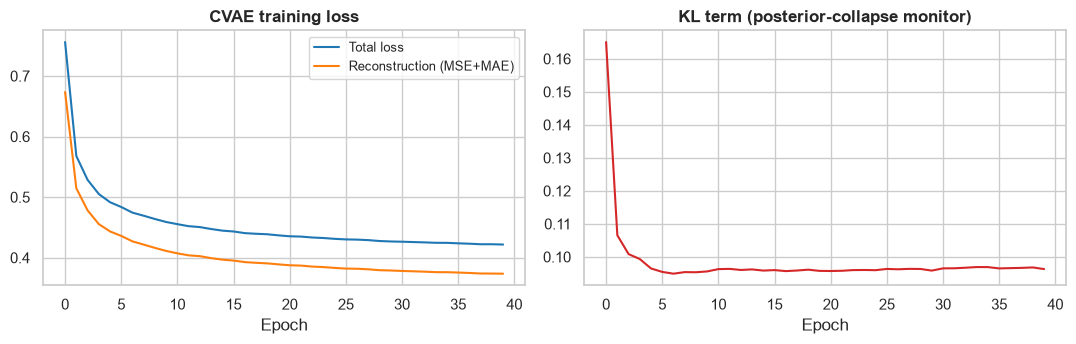

In [36]:
INPUT_DIM = CVAE_X_scaled.shape[1]
LATENT_DIM = 24

set_seed(SEED)
cvae_model = CVAE_TEP(input_dim=INPUT_DIM, n_classes=N_CLASSES, latent_dim=LATENT_DIM, hidden=256).to(DEVICE)
cvae_optimizer = torch.optim.Adam(cvae_model.parameters(), lr=5e-4)

CVAE_EPOCHS = 40
BETA_KL = 0.5  # low, deliberately: Section 4 already showed beta=1.0 causes posterior
                 # collapse on this feature space, so the CVAE uses the same relaxed beta
                 # philosophy as the unconditional VAE (Section 4), not an arbitrary value.

cvae_history = {"loss": [], "recon": [], "kl": []}
print(f"CVAE Training (Beta-VAE with KL weight = {BETA_KL})")
for epoch in range(1, CVAE_EPOCHS + 1):
    cvae_model.train()
    e_loss = e_recon = e_kl = 0.0
    for batch_x, batch_c in cvae_loader:
        batch_x, batch_c = batch_x.to(DEVICE), batch_c.to(DEVICE)

        cvae_optimizer.zero_grad()
        recon_x, mu, logvar = cvae_model(batch_x, batch_c)

        recon_loss = F.mse_loss(recon_x, batch_x, reduction="mean") + F.l1_loss(recon_x, batch_x, reduction="mean")
        kl_div = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + BETA_KL * kl_div

        loss.backward()
        cvae_optimizer.step()
        e_loss += loss.item(); e_recon += recon_loss.item(); e_kl += kl_div.item()

    n_batches = len(cvae_loader)
    cvae_history["loss"].append(e_loss / n_batches)
    cvae_history["recon"].append(e_recon / n_batches)
    cvae_history["kl"].append(e_kl / n_batches)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch [{epoch:2d}/{CVAE_EPOCHS}] | Loss: {cvae_history['loss'][-1]:.4f} "
              f"| Recon: {cvae_history['recon'][-1]:.4f} | KL: {cvae_history['kl'][-1]:.4f}")

# Posterior-collapse check: a KL term that has decayed to ~0 means the decoder is ignoring
# the latent code and conditioning on the class label alone (same failure mode flagged for
# the unconditional VAE in Section 4).
final_kl = cvae_history["kl"][-1]
status = "OK" if final_kl > 0.05 else "WARNING: possible posterior collapse"
print(f"\nFinal mean KL: {final_kl:.4f} nats/sample -> {status}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(cvae_history["loss"], label="Total loss", color="#1f77b4")
axes[0].plot(cvae_history["recon"], label="Reconstruction (MSE+MAE)", color="#ff7f0e")
axes[0].set_xlabel("Epoch"); axes[0].set_title("CVAE training loss", fontweight="bold"); axes[0].legend(fontsize=9)
axes[1].plot(cvae_history["kl"], color="#d62728")
axes[1].set_xlabel("Epoch"); axes[1].set_title("KL term (posterior-collapse monitor)", fontweight="bold")
plt.tight_layout()
plt.show()

### 11.2 Generation and validation: qualitative (PCA) and quantitative (MMD / sliced-Wasserstein)

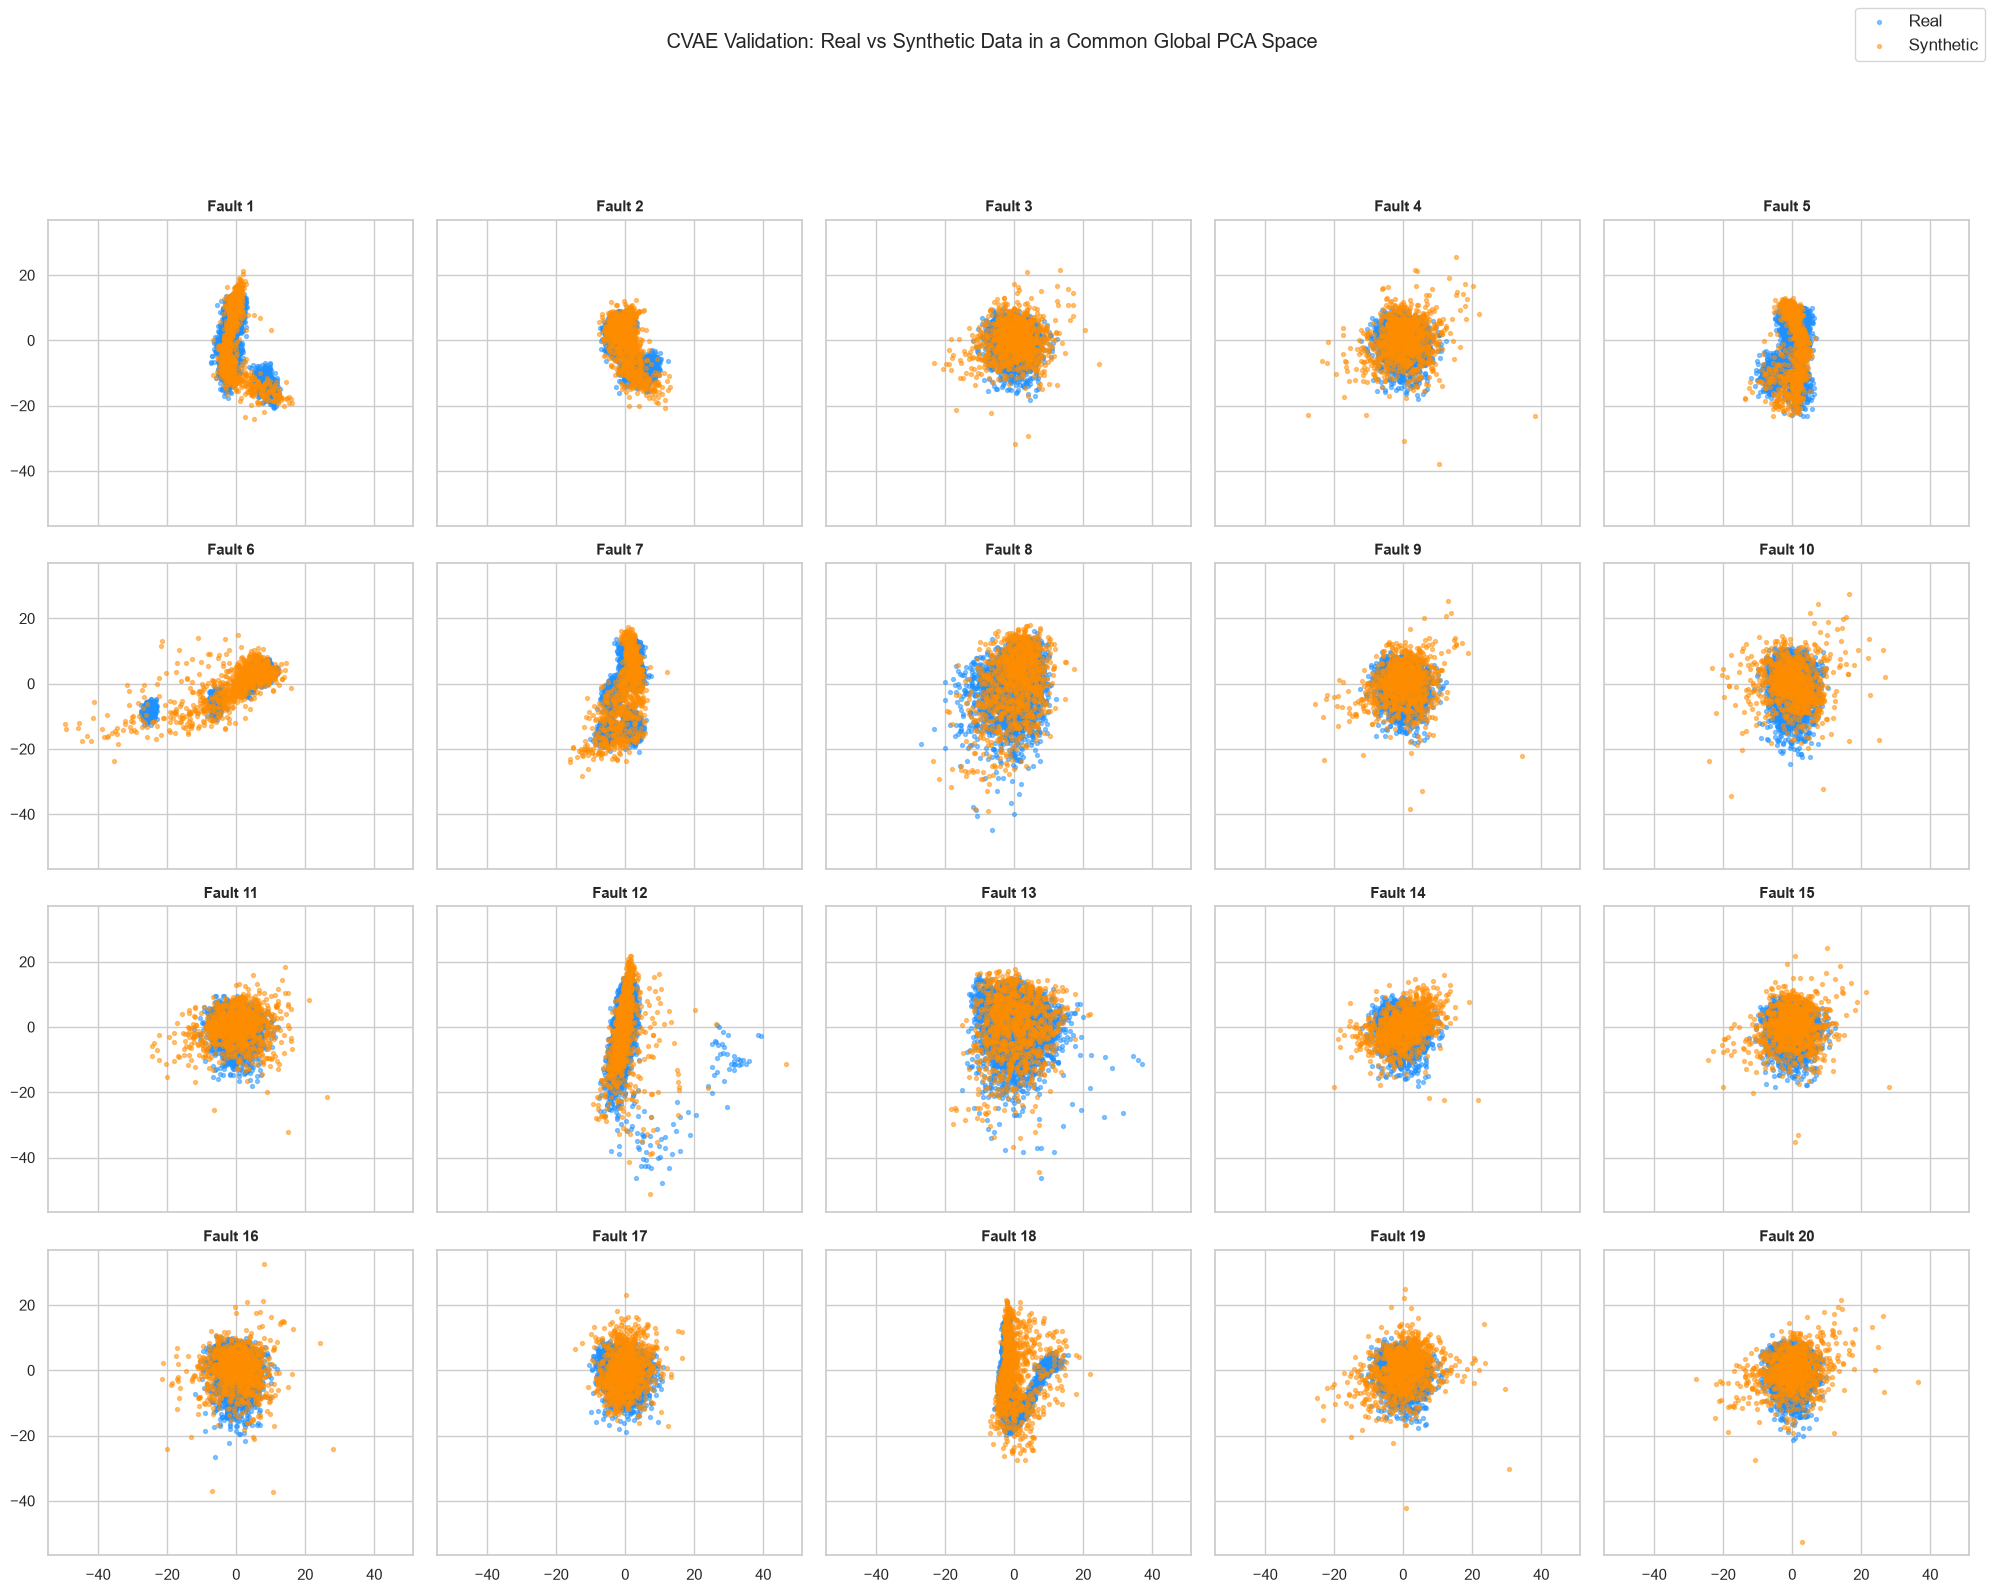

,Fault,MMD,Sliced_Wasserstein,n_real
5,F6,0.072422,0.342147,3500
17,F18,0.072402,0.624692,3500
12,F13,0.033575,0.196253,3500
1,F2,0.029870,0.180478,3500
7,F8,0.027830,0.190688,3500
11,F12,0.024634,0.201808,3500
18,F19,0.019845,0.221378,3500
13,F14,0.017501,0.212999,3500
16,F17,0.017395,0.220680,3500
6,F7,0.017106,0.160768,3500


In [37]:
def generate_tep_samples(model, class_idx, n_samples, feat_mu, feat_sd, n_total_classes,
                          latent_dim, temperature=1.0, seed=SEED):
    """Sample z from the (temperature-scaled) standard normal prior, decode it conditioned
    on `class_idx`, and invert the cvae_scaler standardization back to the original feature
    space. temperature=1.0 matches the training-time prior exactly; values > 1 intentionally
    inflate the sampled cloud and are only meaningful if you have first verified (Section
    11.2 below) that temperature=1.0 already undershoots the real spread — keeping it at the
    training-time default here so the validation below reflects what the model actually
    learned, not an ad hoc correction."""
    g = torch.Generator().manual_seed(seed)
    model.eval()
    with torch.no_grad():
        c_oh = torch.zeros(1, n_total_classes, device=DEVICE)
        c_oh[0, class_idx] = 1.0
        z = torch.randn(n_samples, latent_dim, generator=g, device=DEVICE) * temperature
        x_gen_std = model.decode(z, c_oh.repeat(n_samples, 1))
    return (x_gen_std.cpu().numpy() * feat_sd) + feat_mu


feat_mu = cvae_scaler.mean_
feat_sd = cvae_scaler.scale_

pca_global = PCA(n_components=2)
pca_global.fit(StandardScaler().fit_transform(CVAE_X))

N_SAMPLES_TO_GENERATE = 1000
synthetic_by_fault = {}  
validation_rows = []

fig, axes = plt.subplots(4, 5, figsize=(20, 16), sharex=True, sharey=True)
axes = axes.flatten()

for target_fault in range(1, 21):
    ax = axes[target_fault - 1]

    synthetic_data = generate_tep_samples(
        model=cvae_model, class_idx=target_fault, n_samples=N_SAMPLES_TO_GENERATE,
        feat_mu=feat_mu, feat_sd=feat_sd, n_total_classes=N_CLASSES, latent_dim=LATENT_DIM,
    )
    synthetic_by_fault[target_fault] = synthetic_data

    real_fault_data = CVAE_X[CVAE_y == target_fault]
    if len(real_fault_data) == 0:
        ax.set_title(f"Fault {target_fault} (No Data)")
        ax.axis("off")
        continue

    # Quantitative check, in the *same* standardized space used to train the CVAE
    # (cvae_scaler), not a locally-refit one, so distances are comparable across faults.
    real_scaled = cvae_scaler.transform(real_fault_data)
    synth_scaled = cvae_scaler.transform(synthetic_data)
    validation_rows.append({
        "Fault": f"F{target_fault}",
        "MMD": compute_mmd(real_scaled, synth_scaled),
        "Sliced_Wasserstein": sliced_wasserstein(real_scaled, synth_scaled),
        "n_real": len(real_fault_data),
    })

    real_proj = pca_global.transform(StandardScaler().fit_transform(real_fault_data))
    synth_proj = pca_global.transform(StandardScaler().fit_transform(synthetic_data))

    ax.scatter(real_proj[:, 0], real_proj[:, 1], alpha=0.5, s=8, color="dodgerblue", label="Real")
    ax.scatter(synth_proj[:, 0], synth_proj[:, 1], alpha=0.5, s=8, color="darkorange", label="Synthetic")
    ax.set_title(f"Fault {target_fault}", fontsize=11, fontweight="bold")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize=12)
plt.suptitle("CVAE Validation: Real vs Synthetic Data in a Common Global PCA Space")
plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

df_cvae_validation = pd.DataFrame(validation_rows).sort_values("MMD", ascending=False)
df_cvae_validation

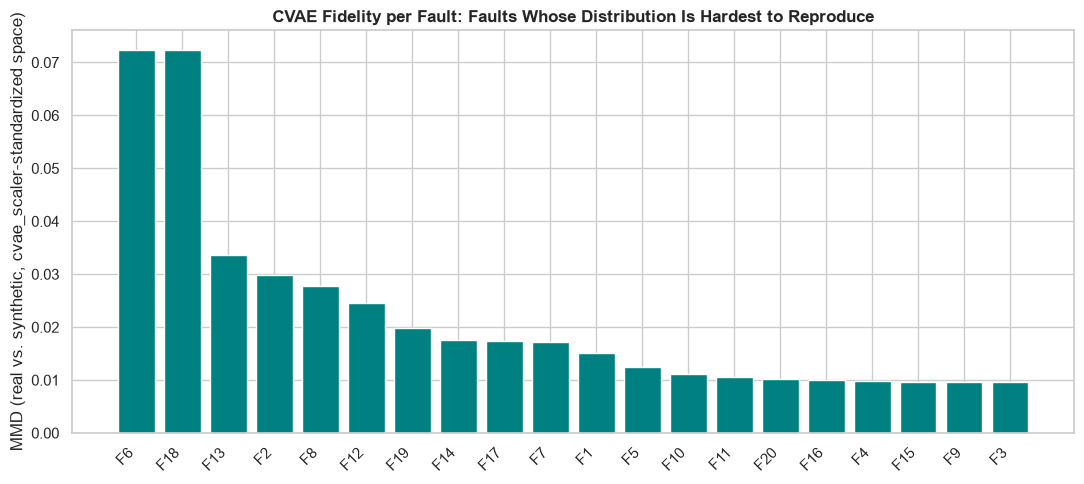

Faults the CVAE reproduces least faithfully (highest MMD):
Fault      MMD  Sliced_Wasserstein  n_real
   F6 0.072422            0.342147    3500
  F18 0.072402            0.624692    3500
  F13 0.033575            0.196253    3500


In [38]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df_cvae_validation))
ax.bar(x, df_cvae_validation["MMD"], color="teal")
ax.set_xticks(x)
ax.set_xticklabels(df_cvae_validation["Fault"], rotation=45, ha="right")
ax.set_ylabel("MMD (real vs. synthetic, cvae_scaler-standardized space)")
ax.set_title("CVAE Fidelity per Fault: Faults Whose Distribution Is Hardest to Reproduce", fontweight="bold")
plt.tight_layout()
plt.show()

print("Faults the CVAE reproduces least faithfully (highest MMD):")
print(df_cvae_validation.head(3).to_string(index=False))

### 11.3 Does synthetic augmentation actually help zero-shot transfer?

A CVAE that scores well on Section 11.2 is not automatically *useful*. Section 9 already
ran a full pairwise transfer matrix and computed a `Transfer_ratio` for every source→target
pair — we reuse that result to find the single worst-transferring pair, then ask a concrete
question: if instead of collecting more real target-fault data we generate synthetic
target-fault windows with the CVAE and add them to the source-domain training set, does the
zero-shot AUC on the real target test set move up toward the in-domain oracle?

This mirrors the augmentation sweep from the 3W notebook (real generator vs. no augmentation,
evaluated on a fixed real test set), adapted from a classification F1 target to the
reconstruction-based anomaly-detection AUC used throughout this notebook.

In [39]:
# Worst pairwise transfer scenario from Section 9 (df_pairwise), used as the testbed.
weakest = df_pairwise.dropna(subset=["Transfer_ratio"]).sort_values("Transfer_ratio").iloc[0]
WEAK_SOURCE, WEAK_TARGET = int(weakest["Source"]), int(weakest["Target"])
oracle_auc_weak = oracle_auc_cache[WEAK_TARGET]
print(f"Weakest zero-shot pair: F{WEAK_SOURCE} -> F{WEAK_TARGET} "
      f"(Transfer_ratio={weakest['Transfer_ratio']:.3f}, in-domain oracle AUC={oracle_auc_weak:.3f})")


def augment_with_synthetic(source_faults: list, target_fault: int, n_synth: int, seed: int = SEED) -> np.ndarray:
    """Source-domain training windows (Section 6 convention) plus n_synth CVAE-generated
    target-fault windows. Both pieces live in the original, unscaled feature space
    (build_domain_training_set returns raw DOMAIN_FEATURES windows; generate_tep_samples
    inverts back through cvae_scaler), so they can be concatenated directly and passed
    through the *same* `scaler` used everywhere else in the transfer-learning framework."""
    X_base = build_domain_training_set([source_faults] if isinstance(source_faults, int) else source_faults,
                                        balance=True, seed=seed)
    if n_synth == 0:
        return X_base
    X_synth = generate_tep_samples(
        model=cvae_model, class_idx=target_fault, n_samples=n_synth,
        feat_mu=feat_mu, feat_sd=feat_sd, n_total_classes=N_CLASSES, latent_dim=LATENT_DIM, seed=seed,
    )
    return np.vstack([X_base, X_synth])


def run_synthetic_augmentation_scenario(source_faults, target_fault: int, n_synth: int,
                                         epochs: int = 30, latent_dim: int = 16) -> float:
    set_seed(SEED)
    X_scaled = scaler.transform(augment_with_synthetic(source_faults, target_fault, n_synth))
    model = train_vae(X_scaled, latent_dim=latent_dim, epochs=epochs, beta=0.5)
    return evaluate_on_target(model, target_fault)["AUC"]

Weakest zero-shot pair: F16 -> F15 (Transfer_ratio=0.782, in-domain oracle AUC=0.129)


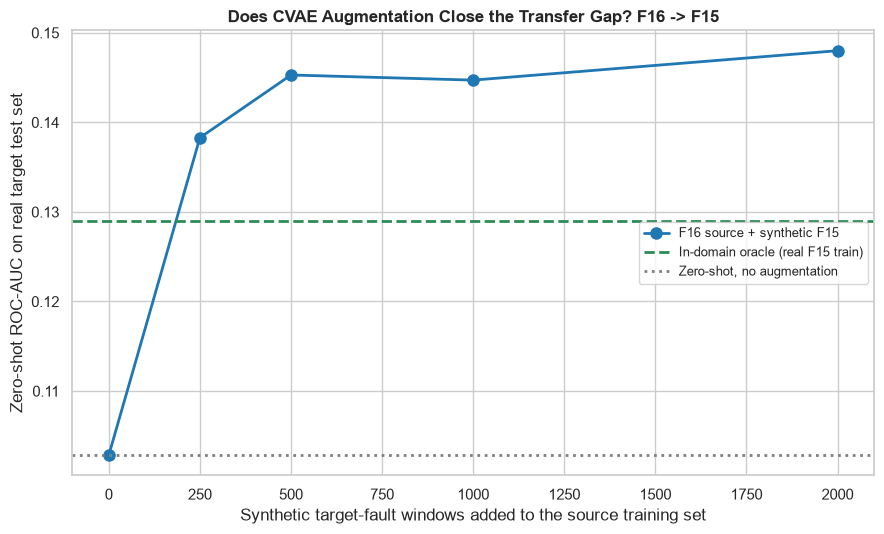

Best synthetic-augmented AUC: 0.148 at n_synth=2000 (recovers 114.7% of the in-domain oracle, vs. 79.7% with no augmentation)


In [40]:
N_SYNTH_SWEEP = [0, 250, 500, 1000, 2000]

aug_results = [
    {"n_synth": n, "AUC": run_synthetic_augmentation_scenario(WEAK_SOURCE, WEAK_TARGET, n)}
    for n in N_SYNTH_SWEEP
]
df_aug = pd.DataFrame(aug_results)
df_aug["Transfer_ratio"] = df_aug["AUC"] / oracle_auc_weak
df_aug

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(df_aug["n_synth"], df_aug["AUC"], "o-", color="#1f77b4", linewidth=2, markersize=8,
        label=f"F{WEAK_SOURCE} source + synthetic F{WEAK_TARGET}")
ax.axhline(oracle_auc_weak, color="seagreen", linestyle="--", linewidth=2,
           label=f"In-domain oracle (real F{WEAK_TARGET} train)")
ax.axhline(df_aug.loc[df_aug["n_synth"] == 0, "AUC"].iloc[0], color="gray", linestyle=":", linewidth=2,
           label="Zero-shot, no augmentation")
ax.set_xlabel("Synthetic target-fault windows added to the source training set")
ax.set_ylabel("Zero-shot ROC-AUC on real target test set")
ax.set_title(f"Does CVAE Augmentation Close the Transfer Gap? F{WEAK_SOURCE} -> F{WEAK_TARGET}", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

best_row = df_aug.loc[df_aug["AUC"].idxmax()]
print(f"Best synthetic-augmented AUC: {best_row['AUC']:.3f} at n_synth={int(best_row['n_synth'])} "
      f"(recovers {100 * best_row['Transfer_ratio']:.1f}% of the in-domain oracle, "
      f"vs. {100 * df_aug.loc[df_aug['n_synth'] == 0, 'Transfer_ratio'].iloc[0]:.1f}% with no augmentation)")

## 12. Correlation Analysis: Domain Discrepancy vs. Transferability

To rigorously understand what dictates the success of zero-shot transfer, we evaluate the statistical relationship between quantitative domain discrepancy metrics (Maximum Mean Discrepancy, Wasserstein distance, and Mahalanobis distance) and the empirical Transfer Ratios across all pairwise fault combinations.

By correlating feature-space shift with cross-domain performance, we test whether structural and physical similarity directly translates to higher generalizability. A strong inverse correlation provides quantitative proof that the VAE's zero-shot reconstruction-based anomaly detection successfully leverages shared process geometries between related source and target domains.

In [41]:
# compute_mmd is now defined in Section 11.0 and reused here.

def compute_mahalanobis(source_scaled: np.ndarray, target_scaled: np.ndarray) -> float:
    """Average Mahalanobis distance of target points from the source centroid,
    using the source's covariance (diagonally regularized for numerical stability)."""
    mean_vec = source_scaled.mean(axis=0)
    cov = np.cov(source_scaled, rowvar=False) + np.eye(source_scaled.shape[1]) * 1e-5
    try:
        inv_cov = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        inv_cov = np.linalg.pinv(cov)
    diff = target_scaled - mean_vec
    return float(np.mean(np.sqrt(np.sum((diff @ inv_cov) * diff, axis=1))))


def compute_centroid_distance(source_scaled: np.ndarray, target_scaled: np.ndarray) -> float:
    """Euclidean distance between the two domains' feature-space centroids."""
    return float(np.linalg.norm(source_scaled.mean(axis=0) - target_scaled.mean(axis=0)))


def evaluate_domain_shift(df_source: pd.DataFrame, df_target: pd.DataFrame,
                           feature_names: list, pair_name: str,
                           top_n: int = 10, make_plot: bool = True) -> dict:
    """Compute all four discrepancy metrics for a source -> target pair, in a
    single scaler fit on the source domain, and plot the top-N most shifted
    features by Wasserstein distance."""
    scaler = StandardScaler().fit(df_source[feature_names])
    s_scaled = scaler.transform(df_source[feature_names])
    t_scaled = scaler.transform(df_target[feature_names])

    mmd_val = compute_mmd(s_scaled, t_scaled)
    w_distances = [wasserstein_distance(s_scaled[:, i], t_scaled[:, i]) for i in range(len(feature_names))]
    mahal_val = compute_mahalanobis(s_scaled, t_scaled)
    centroid_val = compute_centroid_distance(s_scaled, t_scaled)

    avg_w, max_w = float(np.mean(w_distances)), float(np.max(w_distances))

    print(f"Evaluation of {pair_name}")
    print(f"MMD: {mmd_val:.5f}")
    print(f"Wasserstein (avg feature): {avg_w:.5f}")
    print(f"Wasserstein (max feature): {max_w:.5f}")
    print(f"Mahalanobis (target centroid vs source): {mahal_val:.3f}")
    print(f"Centroid distance (Euclidean): {centroid_val:.5f}\n")

    if make_plot:
        df_sorted = (pd.DataFrame({"Feature": feature_names, "Wasserstein": w_distances})
                       .sort_values("Wasserstein", ascending=False)
                       .head(top_n)
                       .set_index("Feature"))
        plt.figure(figsize=(6, max(3, top_n * 0.3)))
        sns.heatmap(df_sorted, cmap="crest", annot=True, fmt=".2f", cbar=True,
                    cbar_kws={"label": "Wasserstein distance (source-std units)"}, linewidths=0.5)
        plt.title(f"Top {top_n} Most-Shifted Features: {pair_name}", fontsize=10)
        plt.ylabel("TEP process variable")
        plt.tight_layout()
        plt.show()

    return {"Scenario": pair_name, "MMD": mmd_val, "Wasserstein_Avg": avg_w,
            "Wasserstein_Max": max_w, "Mahalanobis": mahal_val, "Centroid_Distance": centroid_val}


Evaluation of F2 -> F1
MMD: 0.35725
Wasserstein (avg feature): 5.27879
Wasserstein (max feature): 90.63719
Mahalanobis (target centroid vs source): 193.288
Centroid distance (Euclidean): 242.51551

Evaluation of F3 -> F1
MMD: 0.19683
Wasserstein (avg feature): 4.73316
Wasserstein (max feature): 104.58958
Mahalanobis (target centroid vs source): 169.682
Centroid distance (Euclidean): 253.97114

Evaluation of F4 -> F1
MMD: 0.19733
Wasserstein (avg feature): 5.16418
Wasserstein (max feature): 104.56971
Mahalanobis (target centroid vs source): 179.166
Centroid distance (Euclidean): 264.34902

Evaluation of F5 -> F1
MMD: 0.40237
Wasserstein (avg feature): 2.24979
Wasserstein (max feature): 56.10167
Mahalanobis (target centroid vs source): 240.232
Centroid distance (Euclidean): 124.27534

Evaluation of F6 -> F1
MMD: 0.28374
Wasserstein (avg feature): 190.92187
Wasserstein (max feature): 34929.36571
Mahalanobis (target centroid vs source): 43438.515
Centroid distance (Euclidean): 37907.72828


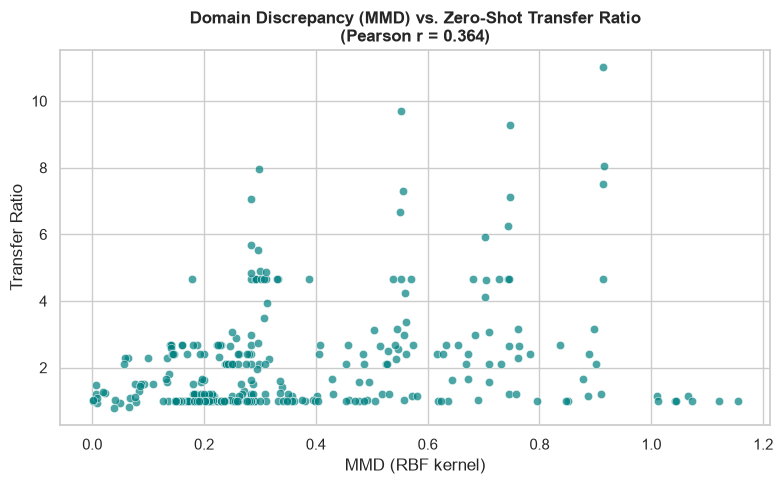

In [42]:
pairwise_shift_records = []

for target in PAIRWISE_FAULTS:
    for source in PAIRWISE_FAULTS:
        if source == target:
            continue
            
        # Preleviamo gli array da DOMAIN_FEATURES
        X_src_eval = DOMAIN_FEATURES[source]["test"]
        X_tgt_eval = DOMAIN_FEATURES[target]["test"]
        
        if len(X_src_eval) == 0 or len(X_tgt_eval) == 0:
            continue
            
        # CONVERSIONE CORRETTA in DataFrame Pandas per la funzione evaluate_domain_shift
        df_src_eval = pd.DataFrame(X_src_eval, columns=FEATURE_NAMES)
        df_tgt_eval = pd.DataFrame(X_tgt_eval, columns=FEATURE_NAMES)
        
        # Calcoliamo le metriche di shift senza generare plot per ogni iterazione
        shift_metrics = evaluate_domain_shift(
            df_src_eval, df_tgt_eval, FEATURE_NAMES, 
            pair_name=f"F{source} -> F{target}", top_n=10, make_plot=False
        )
        
        try:
            ratio = df_pairwise[(df_pairwise["Source"] == source) & (df_pairwise["Target"] == target)]["Transfer_ratio"].values[0]
            if not np.isnan(ratio):
                shift_metrics["Transfer_Ratio"] = ratio
                pairwise_shift_records.append(shift_metrics)
        except (IndexError, KeyError):
            pass

df_shift_corr = pd.DataFrame(pairwise_shift_records)

if not df_shift_corr.empty and "Transfer_Ratio" in df_shift_corr.columns:
    corr_mmd, p_mmd = pearsonr(df_shift_corr["MMD"], df_shift_corr["Transfer_Ratio"])
    corr_wass, p_wass = pearsonr(df_shift_corr["Wasserstein_Avg"], df_shift_corr["Transfer_Ratio"])
    
    print(f"\nCorrelation Analysis")
    print(f"Pearson r (MMD vs Transfer Ratio): {corr_mmd:.3f} (p-value: {p_mmd:.4f})")
    print(f"Pearson r (Avg Wasserstein vs Transfer Ratio): {corr_wass:.3f} (p-value: {p_wass:.4f})")
   
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_shift_corr, x="MMD", y="Transfer_Ratio", alpha=0.7, color="teal")
    plt.title(f"Domain Discrepancy (MMD) vs. Zero-Shot Transfer Ratio\n(Pearson r = {corr_mmd:.3f})", fontweight="bold")
    plt.xlabel("MMD (RBF kernel)")
    plt.ylabel("Transfer Ratio")
    plt.tight_layout()
    plt.show()


--- Correlation Analysis ---
Pearson r (MMD vs Transfer Ratio): 0.364 (p-value: 0.0000)
Pearson r (Avg Wasserstein vs Transfer Ratio): -0.015 (p-value: 0.7742)


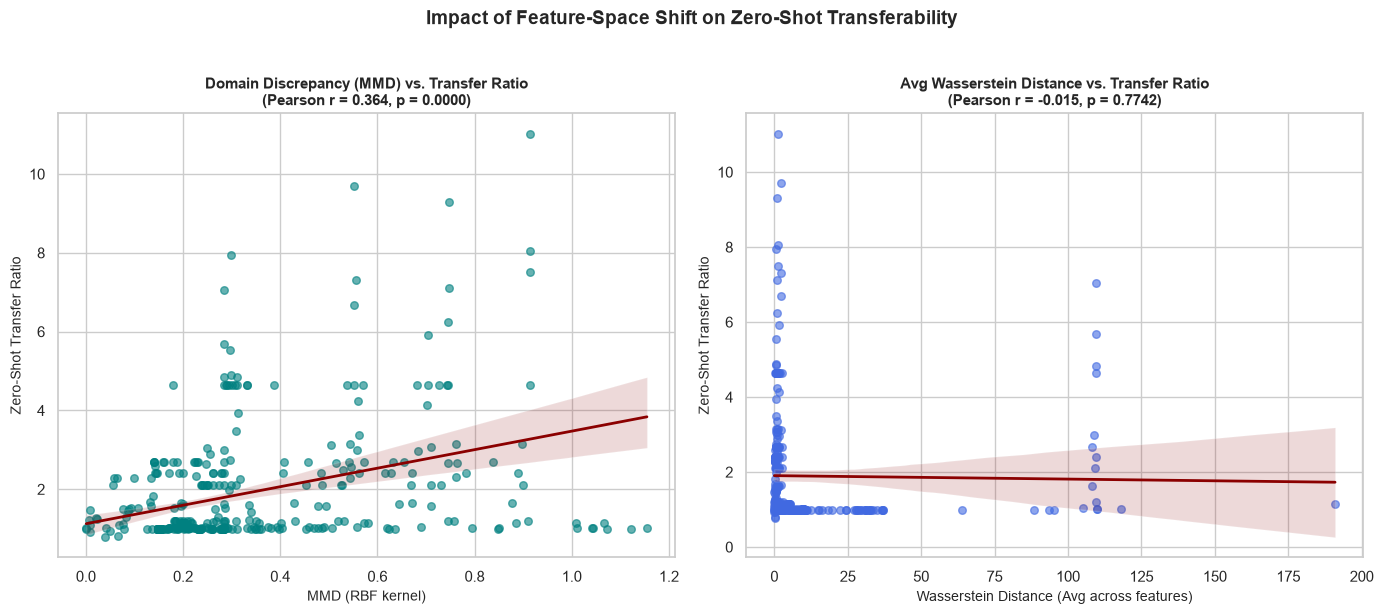

In [43]:
if not df_shift_corr.empty and "Transfer_Ratio" in df_shift_corr.columns:
    corr_mmd, p_mmd = pearsonr(df_shift_corr["MMD"], df_shift_corr["Transfer_Ratio"])
    corr_wass, p_wass = pearsonr(df_shift_corr["Wasserstein_Avg"], df_shift_corr["Transfer_Ratio"])
    
    print(f"\n--- Correlation Analysis ---")
    print(f"Pearson r (MMD vs Transfer Ratio): {corr_mmd:.3f} (p-value: {p_mmd:.4f})")
    print(f"Pearson r (Avg Wasserstein vs Transfer Ratio): {corr_wass:.3f} (p-value: {p_wass:.4f})")
    

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Subplot 1: MMD vs Transfer Ratio
    sns.regplot(
        data=df_shift_corr, x="MMD", y="Transfer_Ratio", ax=axes[0],
        color="teal", scatter_kws={"alpha": 0.6, "s": 30}, line_kws={"color": "darkred", "linewidth": 2}
    )
    axes[0].set_title(f"Domain Discrepancy (MMD) vs. Transfer Ratio\n(Pearson r = {corr_mmd:.3f}, p = {p_mmd:.4f})", fontweight="bold", fontsize=11)
    axes[0].set_xlabel("MMD (RBF kernel)", fontsize=10)
    axes[0].set_ylabel("Zero-Shot Transfer Ratio", fontsize=10)
    
    # Subplot 2: Wasserstein Avg vs Transfer Ratio
    sns.regplot(
        data=df_shift_corr, x="Wasserstein_Avg", y="Transfer_Ratio", ax=axes[1],
        color="royalblue", scatter_kws={"alpha": 0.6, "s": 30}, line_kws={"color": "darkred", "linewidth": 2}
    )
    axes[1].set_title(f"Avg Wasserstein Distance vs. Transfer Ratio\n(Pearson r = {corr_wass:.3f}, p = {p_wass:.4f})", fontweight="bold", fontsize=11)
    axes[1].set_xlabel("Wasserstein Distance (Avg across features)", fontsize=10)
    axes[1].set_ylabel("Zero-Shot Transfer Ratio", fontsize=10)
    
    plt.suptitle("Impact of Feature-Space Shift on Zero-Shot Transferability", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()